# 05 - CCHP & Efficiency Optimization
**Team:** Artemis  
**Project:** SPE Africa Energython 2026 - Molecule to Megabyte

This notebook models the Combined Cooling, Heat, and Power (CCHP) system. By recovering waste heat from the J624 engines to drive absorption chillers, we significantly reduce the electrical cooling load and improve overall Power Usage Effectiveness (PUE).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# J624 Thermal Data per engine
electrical_kw = 4450
exhaust_heat_kw = 2410
jacket_water_heat_kw = 1200
lube_oil_heat_kw = 390
intercooler_heat_kw = 180 # Lower grade, might not be suitable for single-stage LiBr

total_usable_heat_kw = exhaust_heat_kw + jacket_water_heat_kw + lube_oil_heat_kw
engines_online = 4
total_heat_available_kw = total_usable_heat_kw * engines_online

print(f"Usable Heat per Engine: {total_usable_heat_kw} kWth")
print(f"Total Usable Heat (4 Engines): {total_heat_available_kw} kWth")


Usable Heat per Engine: 4000 kWth
Total Usable Heat (4 Engines): 16000 kWth


## 05.1 Absorption Chiller Sizing

Single-stage Lithium Bromide (LiBr) absorption chillers typically operate with a Coefficient of Performance (COP) of ~0.7 to 0.75 when driven by hot water (jacket water) and up to 1.35 if driven directly by exhaust gas (two-stage). For this model, we'll assume a blended conservative COP of 1.2 using a mix of exhaust and jacket water.


In [2]:
absorption_cop = 1.2
cooling_delivered_kw = total_heat_available_kw * absorption_cop

print(f"Cooling Delivered via Waste Heat: {cooling_delivered_kw / 1000:.2f} MW (refrigeration)")

# Baseline electrical cooling required for 15 MW IT load assuming a cooling load factor of 35%
baseline_cooling_load_kw = 15000 * 0.35
print(f"Baseline Cooling Demand: {baseline_cooling_load_kw / 1000:.2f} MW")

cooling_deficit_kw = baseline_cooling_load_kw - cooling_delivered_kw
if cooling_deficit_kw > 0:
    print(f"Cooling Deficit (needs electrical chillers): {cooling_deficit_kw / 1000:.2f} MW")
else:
    print(f"Excess Cooling Capacity: {-cooling_deficit_kw / 1000:.2f} MW")
    cooling_deficit_kw = 0


Cooling Delivered via Waste Heat: 19.20 MW (refrigeration)
Baseline Cooling Demand: 5.25 MW
Excess Cooling Capacity: 13.95 MW


## 05.2 PUE Impact

The CCHP system reduces the electrical demand of the facility, directly improving the PUE.


PUE without CCHP: 1.120
PUE with CCHP: 1.050


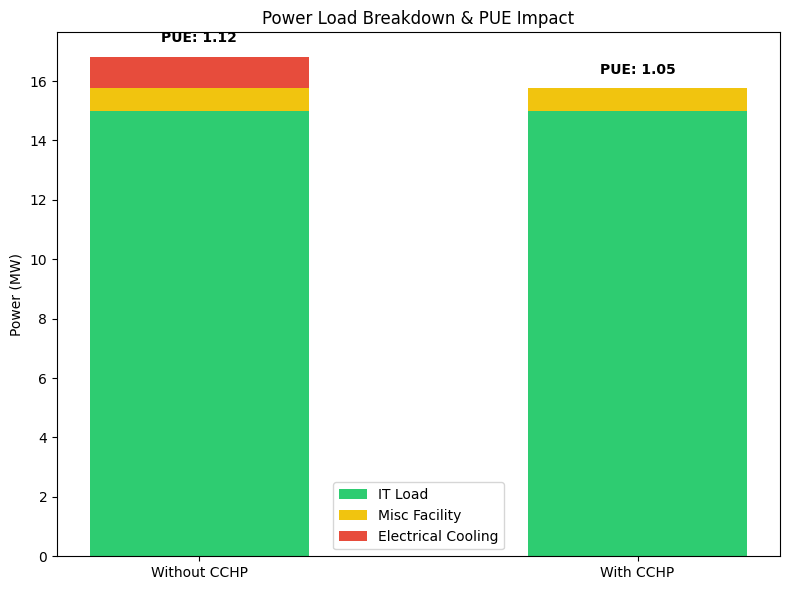

In [3]:
# Conventional Electric Chiller COP
electric_chiller_cop = 5.0
electrical_cooling_kw_without_cchp = baseline_cooling_load_kw / electric_chiller_cop
electrical_cooling_kw_with_cchp = cooling_deficit_kw / electric_chiller_cop

misc_facility_kw = 15000 * 0.05 # Lighting, losses, IT aux

pue_without = (15000 + electrical_cooling_kw_without_cchp + misc_facility_kw) / 15000
pue_with = (15000 + electrical_cooling_kw_with_cchp + misc_facility_kw) / 15000

print(f"PUE without CCHP: {pue_without:.3f}")
print(f"PUE with CCHP: {pue_with:.3f}")

# Plotting the PUE Breakdown
labels = ['Without CCHP', 'With CCHP']
it_load = [15.0, 15.0]
misc_load = [misc_facility_kw/1000, misc_facility_kw/1000]
cooling_load = [electrical_cooling_kw_without_cchp/1000, electrical_cooling_kw_with_cchp/1000]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, it_load, width, label='IT Load', color='#2ecc71')
ax.bar(x, misc_load, width, bottom=it_load, label='Misc Facility', color='#f1c40f')
ax.bar(x, cooling_load, width, bottom=np.array(it_load)+np.array(misc_load), label='Electrical Cooling', color='#e74c3c')

ax.set_ylabel('Power (MW)')
ax.set_title('Power Load Breakdown & PUE Impact')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Annotate PUE
ax.text(0, 15.0 + misc_load[0] + cooling_load[0] + 0.5, f"PUE: {pue_without:.2f}", ha='center', fontweight='bold')
ax.text(1, 15.0 + misc_load[1] + cooling_load[1] + 0.5, f"PUE: {pue_with:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/05_pue_comparison.png', dpi=300)
plt.show()
